## Algerian Forest Fires Dataset 
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

In [325]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [326]:
frst = pd.read_csv("Datasets/Algerian_forest_fires_dataset_UPDATE.csv",header=1)

In [327]:
frst.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [328]:
frst.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 38.2 KB


In [329]:
# Data Cleaning
frst[frst.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [330]:
frst.dropna(inplace=True)

The dataset is converted into two sets based on Region from 122th index, we can make a new column based on the Region.

1: "Bejaia Region Dataset"
2: "Sidi-Bel Abbes Region Dataset"

In [331]:
frst.loc[:122,'Region']=0
frst.loc[122:,'Region']=1

In [332]:
frst['Region'] = frst['Region'].astype(int)

In [333]:
frst.iloc[[121]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
121,30,09,2012,25,78,14,1.4,45,1.9,7.5,0.2,2.4,0.1,not fire,0


In [334]:
frst = frst.drop([123]).reset_index(drop=True)

In [335]:
frst.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

In [336]:
# fix spaces in  columns names
frst.columns=frst.columns.str.strip()

In [337]:
frst.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

Fixing data entries to convert the columns to its respective datatypes

In [338]:
object_cols = ["Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]

In [339]:
for col in object_cols:
    frst[col] = frst[col].str.strip()

In [340]:
frst['DC'][frst['DC']=='14.6 9']

Series([], Name: DC, dtype: str)

In [341]:
frst['DC'].iloc[165]

'24.1'

In [342]:
frst.loc[165,'DC'] = '14.69'

In [343]:
frst['FWI'][frst['FWI']=='fire']

Series([], Name: FWI, dtype: str)

In [344]:
frst['FWI'].iloc[165]

'14.1'

In [345]:
frst.loc[165,'FWI'] = '7.04'  #Mean of the column FMI

In [346]:
frst['FWI'].iloc[165]

'7.04'

In [347]:
# Change required columns as int or float datatype after fixing data entries
frst[["day", "month", "year", "Temperature", "RH", "Ws"]] = frst[
    ["day", "month", "year", "Temperature", "RH", "Ws"]
].astype(int)
frst[["Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]] = frst[
    ["Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]
].astype(float)

In [348]:
frst.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 30.7 KB


In [349]:
frst.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [350]:
# Saving cleaned dataset
frst.to_csv('Datasets/Algerian_forest_fires_cleaned.csv',index=False)

In [351]:
# Exploratory Data Analysis (EDA)
frst_copy = frst.copy()

In [352]:
frst_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [353]:
frst_copy.drop(['day','month','year'],inplace=True,axis=1)

In [354]:
# Encoding of the categories in Classes

frst_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [355]:
frst_copy['Classes'] = np.where(frst_copy['Classes'].str.contains('not fire'),0,1)

In [356]:
frst_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

array([[<Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'Temperature'}>],
       [<Axes: title={'center': 'RH'}>, <Axes: title={'center': 'Ws'}>,
        <Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'FFMC'}>],
       [<Axes: title={'center': 'DMC'}>, <Axes: title={'center': 'DC'}>,
        <Axes: title={'center': 'ISI'}>, <Axes: title={'center': 'BUI'}>],
       [<Axes: title={'center': 'FWI'}>,
        <Axes: title={'center': 'Region'}>, <Axes: >, <Axes: >]],
      dtype=object)

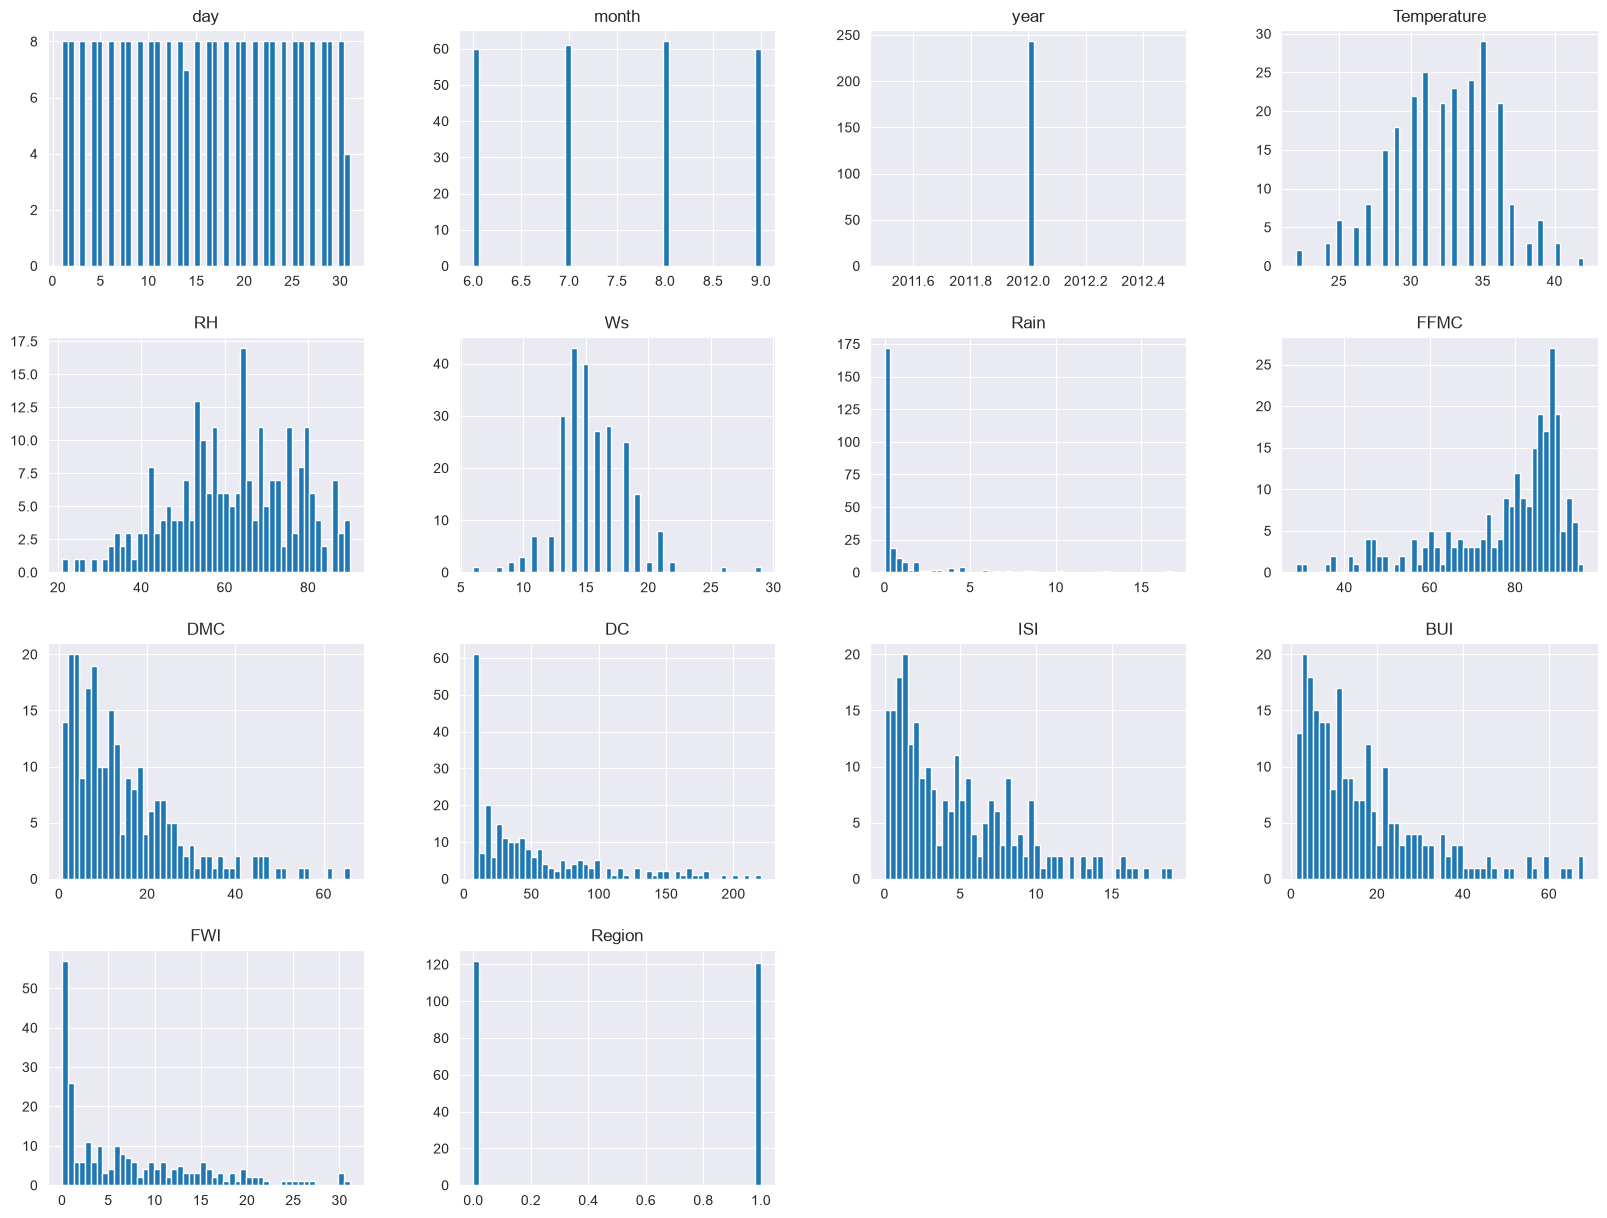

In [357]:

frst.hist(bins=50,figsize=(20,15))

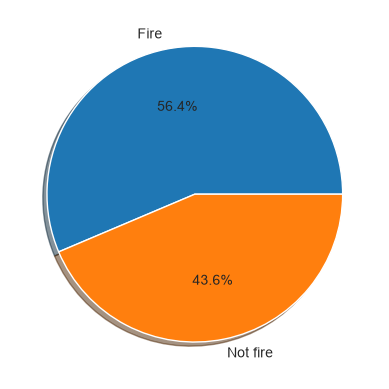

In [358]:
# Pie chart for Classes column
percentage = frst_copy['Classes'].value_counts(normalize=True)

plt.pie(percentage,labels=['Fire','Not fire'],autopct='%1.1f%%',shadow=True)

<Axes: >

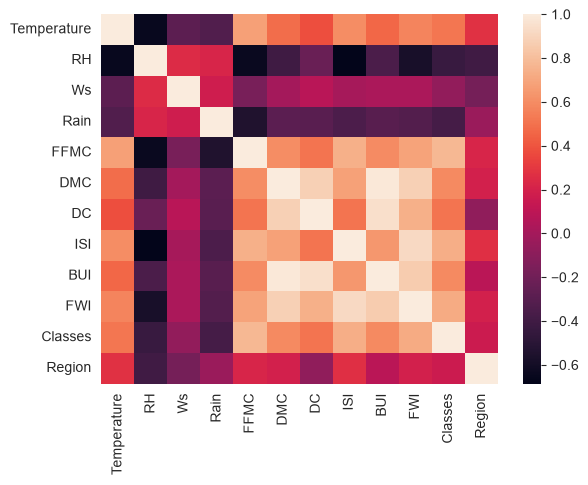

In [359]:
# Correlation

crr = frst_copy.corr()
sns.heatmap(crr)

<Axes: xlabel='FWI'>

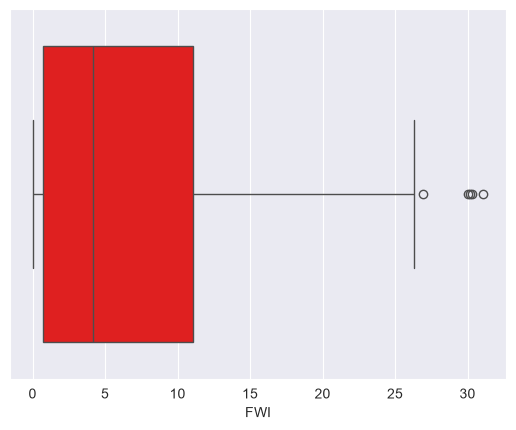

In [360]:
# Box plots

sns.boxplot(x=frst_copy['FWI'],color='r')

In [361]:
# Monthly Fire Analysis
frst['Classes'] = np.where(frst['Classes'].str.contains('not fire'),'Not Fire','Fire')

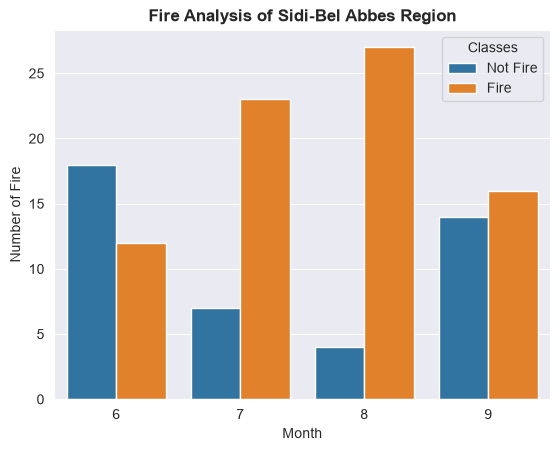

In [362]:
frst_Sidi_Bel_Abbes = frst.loc[frst['Region']==1]
sns.set_style('darkgrid')
sns.countplot(x='month',hue='Classes',data=frst_Sidi_Bel_Abbes)
plt.ylabel('Number of Fire')
plt.xlabel('Month')
plt.title('Fire Analysis of Sidi-Bel Abbes Region',weight='bold')
plt.show()

In [364]:
# Saving the dataset for training
frst_copy.to_csv('Datasets/Algerian_forest_fires_train.csv',index=False)